In [30]:
# ============================================
# Brain Tumor MRI - Data Preprocessing
# SE4050 Deep Learning Assignment
# ============================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")
print("Random seed:", SEED)

Libraries imported successfully.
Random seed: 42


In [31]:
# ============================================
# Dataset Paths
# ============================================

from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset directories
TRAIN_DIR = PROJECT_ROOT / "archive" / "Training"
TEST_DIR = PROJECT_ROOT / "archive" / "Testing"

print("Project root :", PROJECT_ROOT)
print("Training path:", TRAIN_DIR)
print("Testing path :", TEST_DIR)

# Verify paths exist
print("\nPath verification:")
print("Training exists:", TRAIN_DIR.exists())
print("Testing exists :", TEST_DIR.exists())

Project root : /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit
Training path: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/archive/Training
Testing path : /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/archive/Testing

Path verification:
Training exists: True
Testing exists : True


In [32]:
# ============================================
# Dataset Class and Image Count Verification
# ============================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def count_images(folder):
    return sum(
        1 for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

# Get class names
classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print("Classes:", classes)
print()

# Count training images
print("Training dataset:")
training_counts = {}

for class_name in classes:
    class_path = TRAIN_DIR / class_name
    count = count_images(class_path)
    training_counts[class_name] = count
    print(f"{class_name:12s}: {count}")

print(f"\nTotal training images: {sum(training_counts.values())}")

# Count testing images
print("\nTesting dataset:")
testing_counts = {}

for class_name in classes:
    class_path = TEST_DIR / class_name
    count = count_images(class_path)
    testing_counts[class_name] = count
    print(f"{class_name:12s}: {count}")

print(f"\nTotal testing images: {sum(testing_counts.values())}")

# Overall total
total_images = sum(training_counts.values()) + sum(testing_counts.values())
print(f"\nTotal dataset images: {total_images}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training dataset:
glioma      : 1400
meningioma  : 1400
notumor     : 1400
pituitary   : 1400

Total training images: 5600

Testing dataset:
glioma      : 400
meningioma  : 400
notumor     : 400
pituitary   : 400

Total testing images: 1600

Total dataset images: 7200


In [33]:
# ============================================
# Image Quality and Format Check
# ============================================

from collections import Counter

def inspect_images(folder):
    dimension_counts = Counter()
    format_counts = Counter()
    corrupted_files = []

    image_paths = [
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for path in image_paths:
        try:
            with Image.open(path) as img:
                # Check that the image can be fully read
                img.verify()

            # Re-open because verify() invalidates the image object
            with Image.open(path) as img:
                dimension_counts[img.size] += 1
                format_counts[img.format] += 1

        except Exception:
            corrupted_files.append(str(path))

    return dimension_counts, format_counts, corrupted_files


# Inspect Training dataset
train_dimensions, train_formats, train_corrupted = inspect_images(TRAIN_DIR)

# Inspect Testing dataset
test_dimensions, test_formats, test_corrupted = inspect_images(TEST_DIR)


# --------------------------------------------
# Display results
# --------------------------------------------

print("TRAINING DATASET")
print("----------------")
print("Image dimensions:")
for dimension, count in train_dimensions.most_common():
    print(f"{dimension}: {count}")

print("\nImage formats:")
for image_format, count in train_formats.most_common():
    print(f"{image_format}: {count}")

print(f"\nCorrupted training images: {len(train_corrupted)}")


print("\n\nTESTING DATASET")
print("----------------")
print("Image dimensions:")
for dimension, count in test_dimensions.most_common():
    print(f"{dimension}: {count}")

print("\nImage formats:")
for image_format, count in test_formats.most_common():
    print(f"{image_format}: {count}")

print(f"\nCorrupted testing images: {len(test_corrupted)}")


# --------------------------------------------
# Overall summary
# --------------------------------------------

print("\n\nQUALITY SUMMARY")
print("----------------")
print("Total corrupted images:",
      len(train_corrupted) + len(test_corrupted))

TRAINING DATASET
----------------
Image dimensions:
(512, 512): 4012
(225, 225): 253
(630, 630): 69
(201, 251): 40
(236, 236): 39
(442, 442): 38
(150, 198): 33
(232, 217): 32
(228, 221): 32
(428, 417): 31
(200, 252): 29
(206, 244): 26
(201, 250): 26
(173, 201): 26
(192, 192): 25
(256, 256): 22
(218, 231): 22
(227, 222): 20
(227, 262): 19
(214, 236): 19
(468, 444): 19
(215, 234): 19
(236, 213): 17
(504, 540): 17
(359, 449): 16
(208, 242): 16
(230, 282): 15
(550, 664): 15
(400, 442): 15
(393, 400): 14
(442, 454): 13
(441, 442): 13
(339, 340): 12
(680, 680): 12
(196, 257): 11
(350, 350): 11
(207, 243): 11
(276, 326): 11
(235, 214): 10
(420, 280): 10
(356, 474): 8
(300, 168): 8
(212, 238): 8
(194, 259): 8
(380, 530): 7
(275, 183): 6
(350, 393): 6
(177, 197): 6
(236, 357): 5
(1024, 1024): 5
(235, 227): 5
(201, 210): 4
(275, 301): 4
(208, 248): 4
(416, 512): 4
(236, 269): 4
(220, 275): 4
(1338, 1304): 3
(892, 826): 3
(202, 202): 3
(1335, 1302): 3
(624, 607): 3
(900, 741): 3
(785, 848): 3
(64

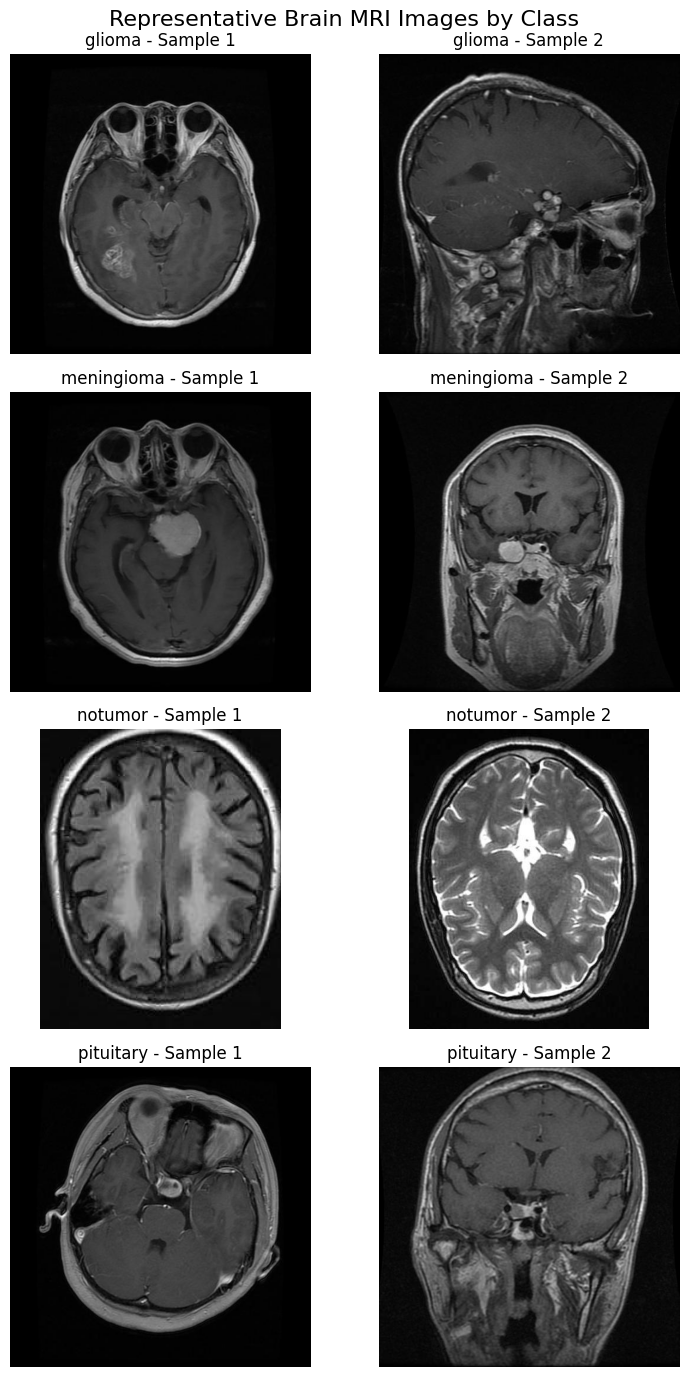

In [34]:
# ============================================
# Visualize Two MRI Samples per Class
# ============================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(8, 14)
)

for row, class_name in enumerate(classes):

    class_path = TRAIN_DIR / class_name

    image_files = [
        path for path in class_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Select two images
    selected_images = image_files[:2]

    for col, image_path in enumerate(selected_images):

        with Image.open(image_path) as img:
            img = img.convert("RGB")

            axes[row, col].imshow(img)
            axes[row, col].set_title(
                f"{class_name} - Sample {col + 1}"
            )
            axes[row, col].axis("off")

plt.suptitle(
    "Representative Brain MRI Images by Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

Training class distribution:


,Class,Count
0,glioma,1400
1,meningioma,1400
2,notumor,1400
3,pituitary,1400



Testing class distribution:


,Class,Count
0,glioma,400
1,meningioma,400
2,notumor,400
3,pituitary,400


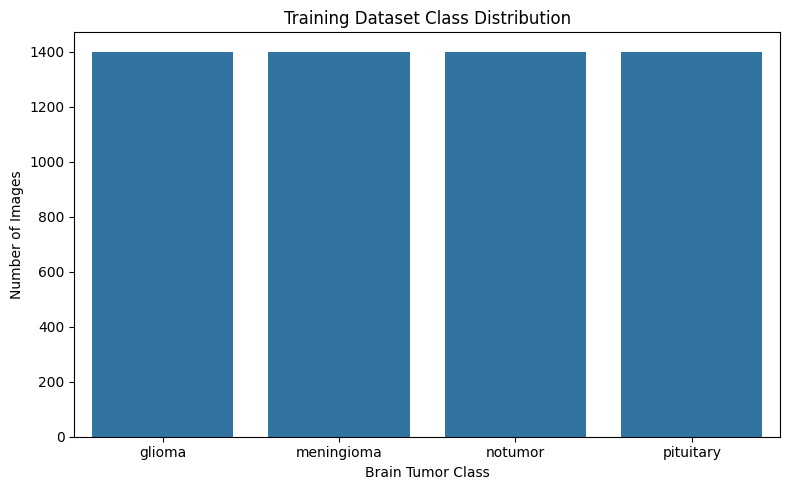

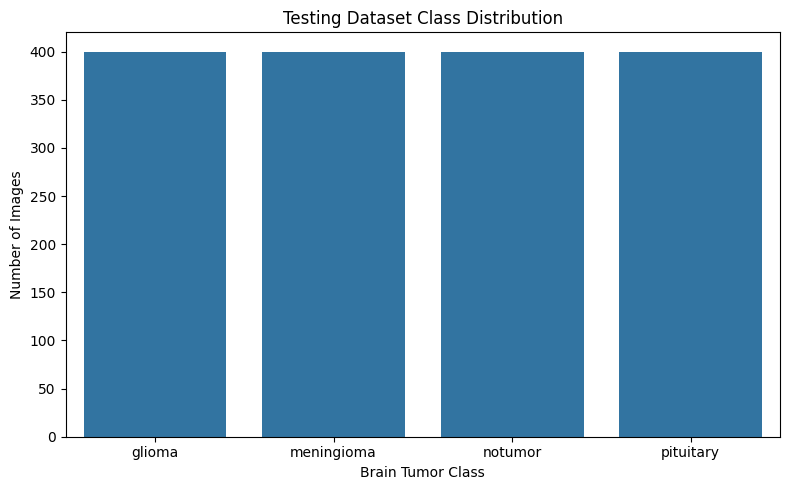

In [35]:
# ============================================
# Class Distribution Analysis
# ============================================

# Create DataFrames for plotting
train_df = pd.DataFrame({
    "Class": list(training_counts.keys()),
    "Count": list(training_counts.values())
})

test_df = pd.DataFrame({
    "Class": list(testing_counts.keys()),
    "Count": list(testing_counts.values())
})

# Display counts
print("Training class distribution:")
display(train_df)

print("\nTesting class distribution:")
display(test_df)

# Plot training distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train_df,
    x="Class",
    y="Count"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# Plot testing distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    data=test_df,
    x="Class",
    y="Count"
)

plt.title("Testing Dataset Class Distribution")
plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [36]:
# ============================================
# Stratified Train / Validation Split
# ============================================

from sklearn.model_selection import train_test_split

# Collect all training image paths and labels
image_paths = []
labels = []

for class_name in classes:
    class_path = TRAIN_DIR / class_name

    for image_path in class_path.iterdir():
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            image_paths.append(str(image_path))
            labels.append(class_name)

# Create dataframe
train_data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total training samples:", len(train_data))
print("\nOriginal class distribution:")
print(train_data["label"].value_counts())

# Stratified 80/20 split
train_split, val_split = train_test_split(
    train_data,
    test_size=0.20,
    random_state=SEED,
    stratify=train_data["label"]
)

# Reset indices
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

# Display results
print("\nSplit results:")
print("Training samples  :", len(train_split))
print("Validation samples:", len(val_split))

print("\nTraining distribution:")
print(train_split["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_split["label"].value_counts().sort_index())

Total training samples: 5600

Original class distribution:
label
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

Split results:
Training samples  : 4480
Validation samples: 1120

Training distribution:
label
glioma        1120
meningioma    1120
notumor       1120
pituitary     1120
Name: count, dtype: int64

Validation distribution:
label
glioma        280
meningioma    280
notumor       280
pituitary     280
Name: count, dtype: int64


In [37]:
# ============================================
# ViT-B/16 Image Preprocessing
# ============================================

from torchvision import transforms

# ViT-B/16 standard input size
IMAGE_SIZE = 224

# ImageNet normalization used for the pretrained ViT
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# --------------------------------------------
# Training transformations
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=7),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# --------------------------------------------
# Validation transformations
# --------------------------------------------
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# --------------------------------------------
# Test transformations
# --------------------------------------------
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Image size:", IMAGE_SIZE)
print("Training transform:", train_transform)
print("Validation transform:", val_transform)
print("Testing transform:", test_transform)

Image size: 224
Training transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-7.0, 7.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Validation transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Testing transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [38]:
# ============================================
# PyTorch Dataset and DataLoader
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader


# Class-to-index mapping
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Class mapping:")
print(class_to_idx)


class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label_name = self.dataframe.loc[index, "label"]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform:
            image = self.transform(image)

        label = class_to_idx[label_name]

        return image, label


# --------------------------------------------
# Create testing dataframe
# --------------------------------------------

test_paths = []
test_labels = []

for class_name in classes:
    class_path = TEST_DIR / class_name

    for image_path in class_path.iterdir():
        if (
            image_path.is_file()
            and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            test_paths.append(str(image_path))
            test_labels.append(class_name)

test_df = pd.DataFrame({
    "image_path": test_paths,
    "label": test_labels
})

print("\nDataset sizes:")
print("Train      :", len(train_split))
print("Validation :", len(val_split))
print("Test       :", len(test_df))


# --------------------------------------------
# Create Dataset objects
# --------------------------------------------

train_dataset = BrainMRIDataset(
    train_split,
    transform=train_transform
)

val_dataset = BrainMRIDataset(
    val_split,
    transform=val_transform
)

test_dataset = BrainMRIDataset(
    test_df,
    transform=test_transform
)


# --------------------------------------------
# Create DataLoaders
# --------------------------------------------

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print("\nDataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Dataset sizes:
Train      : 4480
Validation : 1120
Test       : 1600

DataLoaders created successfully.
Batch size: 4


In [39]:
# ============================================
# Verify One Batch
# ============================================

images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Labels            :", labels.tolist())

print("\nExpected image shape:")
print("[batch_size, channels, height, width]")
print("[4, 3, 224, 224]")

Image batch shape : torch.Size([4, 3, 224, 224])
Label batch shape : torch.Size([4])
Labels            : [3, 1, 2, 1]

Expected image shape:
[batch_size, channels, height, width]
[4, 3, 224, 224]


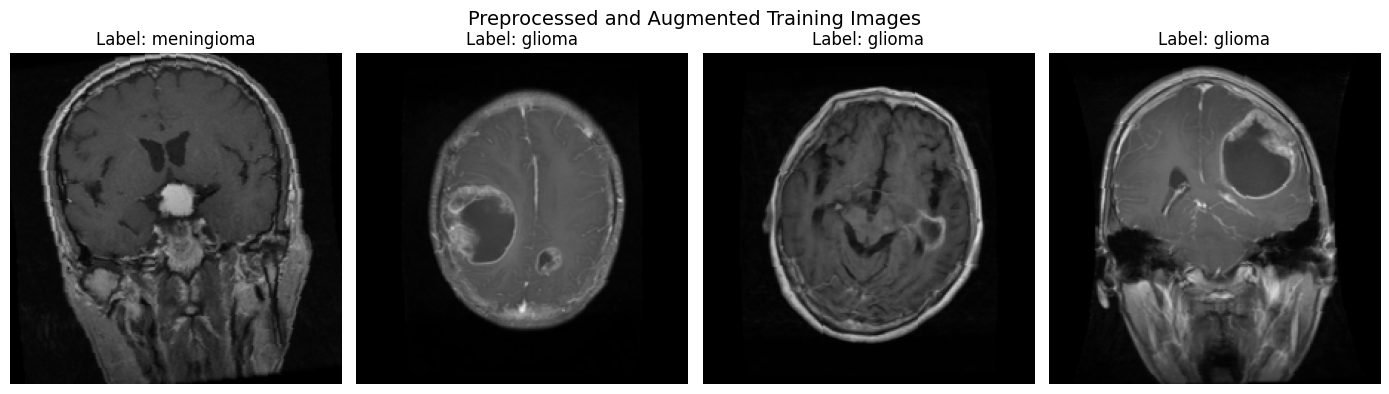

In [40]:
# ============================================
# Visualize Preprocessed / Augmented Images
# ============================================

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

images, labels = next(iter(train_loader))

num_images = len(images)

fig, axes = plt.subplots(
    1,
    num_images,
    figsize=(14, 4)
)

if num_images == 1:
    axes = [axes]

for i in range(num_images):

    # Undo normalization for visualization
    image = images[i].cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    # [C, H, W] → [H, W, C]
    image = image.permute(1, 2, 0).numpy()

    axes[i].imshow(image)
    axes[i].set_title(
        f"Label: {idx_to_class[labels[i].item()]}"
    )
    axes[i].axis("off")

plt.suptitle(
    "Preprocessed and Augmented Training Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [41]:
# ============================================
# Apple M1 GPU / MPS Verification
# ============================================

import torch

print("PyTorch version:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device:", device)
else:
    device = torch.device("cpu")
    print("MPS unavailable. Using CPU.")

PyTorch version: 2.8.0
MPS built: True
MPS available: True
Using device: mps


In [42]:
# ============================================
# Load Pretrained Vision Transformer (ViT-B/16)
# ============================================

import timm
import torch.nn as nn

NUM_CLASSES = 4

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print("Model: ViT-B/16")
print("Number of classes:", NUM_CLASSES)
print("Input size:", (224, 224))
print("Patch size:", (16, 16))

Model: ViT-B/16
Number of classes: 4
Input size: (224, 224)
Patch size: (16, 16)


In [43]:
# ============================================
# ViT-B/16 Model Information
# ============================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nClassification head:")
print(model.head)

Total parameters: 85,801,732
Trainable parameters: 85,801,732

Classification head:
Linear(in_features=768, out_features=4, bias=True)


In [44]:
# ============================================
# Freeze ViT-B/16 Backbone
# ============================================

# Freeze all model parameters
for param in model.parameters():
    param.requires_grad = False

# Keep the classification head trainable
for param in model.head.parameters():
    param.requires_grad = True

# Count trainable parameters
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

print("\nClassification head:")
print(model.head)

Total parameters:     85,801,732
Trainable parameters: 3,076
Frozen parameters:    85,798,656

Classification head:
Linear(in_features=768, out_features=4, bias=True)


In [45]:
# ============================================
# Stage 1 - Loss Function and Optimizer
# ============================================

import torch.optim as optim

# Multi-class classification loss
criterion = nn.CrossEntropyLoss()

# AdamW optimizer
# Only parameters with requires_grad=True are updated
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 1e-3)
print("Weight decay:", 1e-4)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001


In [50]:
# ============================================
# Stage 1 - Training Configuration
# ============================================

NUM_EPOCHS_STAGE1 = 5

# Save trained checkpoints OUTSIDE the Git repository
CHECKPOINT_DIR = Path.home() / "brain-tumor-checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR / "vit_b16_stage1_best.pth"
)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

print("Stage 1 configuration")
print("----------------------")
print("Epochs:", NUM_EPOCHS_STAGE1)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", 1e-3)
print("Checkpoint:", BEST_MODEL_PATH)

Stage 1 configuration
----------------------
Epochs: 5
Batch size: 4
Learning rate: 0.001
Checkpoint: /Users/mirshad/brain-tumor-checkpoints/vit_b16_stage1_best.pth


In [51]:
# ============================================
# Stage 1 - Training and Validation Functions
# ============================================

def calculate_accuracy(outputs, labels):
    """
    Calculate classification accuracy.
    """
    predictions = torch.argmax(outputs, dim=1)
    correct = (predictions == labels).sum().item()
    total = labels.size(0)

    return correct, total


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update trainable parameters
        optimizer.step()

        # Statistics
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        batch_correct, batch_total = calculate_accuracy(
            outputs,
            labels
        )

        correct += batch_correct
        total += batch_total

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model without updating weights.
    """
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Statistics
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size

            batch_correct, batch_total = calculate_accuracy(
                outputs,
                labels
            )

            correct += batch_correct
            total += batch_total

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training and validation functions created successfully.")

Training and validation functions created successfully.


In [52]:
# ============================================
# Stage 1 - Train Classification Head
# ============================================

print("Starting Stage 1 training...")
print("Device:", device)
print("Epochs:", NUM_EPOCHS_STAGE1)
print("Batch size:", BATCH_SIZE)
print()

for epoch in range(NUM_EPOCHS_STAGE1):

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    # Save history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Checkpoint
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        # Save CPU copy for portability
        checkpoint = {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        checkpoint_status = " ← Best model saved"

    else:
        checkpoint_status = ""

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS_STAGE1}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
        f"{checkpoint_status}"
    )

print("\nStage 1 training completed.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best model saved to: {BEST_MODEL_PATH}")

Starting Stage 1 training...
Device: mps
Epochs: 5
Batch size: 4

Epoch [1/5] | Train Loss: 0.3086 | Train Acc: 0.8879 | Val Loss: 0.3990 | Val Acc: 0.8491 ← Best model saved
Epoch [2/5] | Train Loss: 0.2556 | Train Acc: 0.9109 | Val Loss: 0.2684 | Val Acc: 0.9027 ← Best model saved
Epoch [3/5] | Train Loss: 0.2441 | Train Acc: 0.9152 | Val Loss: 0.3833 | Val Acc: 0.8589
Epoch [4/5] | Train Loss: 0.2432 | Train Acc: 0.9143 | Val Loss: 0.3052 | Val Acc: 0.8973
Epoch [5/5] | Train Loss: 0.2247 | Train Acc: 0.9225 | Val Loss: 0.2546 | Val Acc: 0.9214 ← Best model saved

Stage 1 training completed.
Best validation accuracy: 0.9214
Best model saved to: /Users/mirshad/brain-tumor-checkpoints/vit_b16_stage1_best.pth


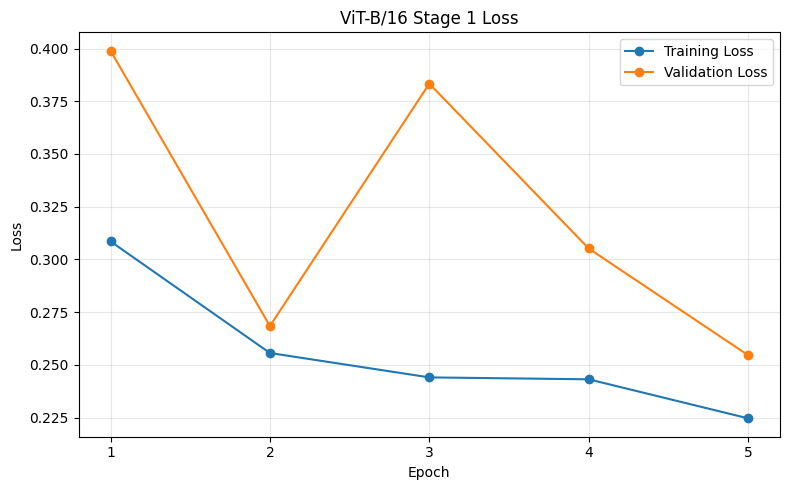

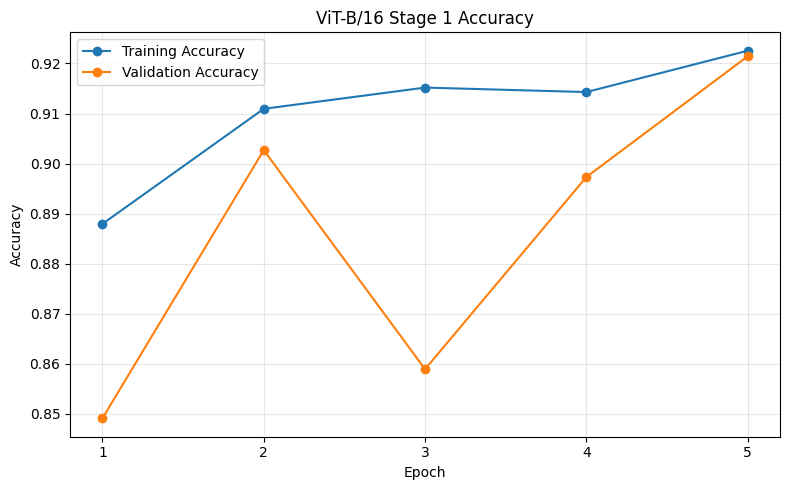

Loss plot saved to: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/figures/vit_stage1_loss.png
Accuracy plot saved to: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/figures/vit_stage1_accuracy.png


In [53]:
# ============================================
# Stage 1 - Learning Curves
# ============================================

epochs = range(1, len(history["train_loss"]) + 1)

# --------------------------------------------
# Loss curve
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT-B/16 Stage 1 Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

loss_plot_path = (
    PROJECT_ROOT / "results" / "figures" / "vit_stage1_loss.png"
)

plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()


# --------------------------------------------
# Accuracy curve
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT-B/16 Stage 1 Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

accuracy_plot_path = (
    PROJECT_ROOT / "results" / "figures" / "vit_stage1_accuracy.png"
)

plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss plot saved to:", loss_plot_path)
print("Accuracy plot saved to:", accuracy_plot_path)

In [54]:
# ============================================
# Save Stage 1 Training History
# ============================================

history_df = pd.DataFrame({
    "Epoch": list(epochs),
    "Train_Loss": history["train_loss"],
    "Train_Accuracy": history["train_accuracy"],
    "Validation_Loss": history["val_loss"],
    "Validation_Accuracy": history["val_accuracy"]
})

history_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "vit_stage1_history.csv"
)

history_df.to_csv(history_path, index=False)

print(history_df)
print("\nTraining history saved to:", history_path)

   Epoch  Train_Loss  Train_Accuracy  Validation_Loss  Validation_Accuracy
0      1    0.308573        0.887946         0.398960             0.849107
1      2    0.255640        0.910937         0.268436             0.902679
2      3    0.244085        0.915179         0.383345             0.858929
3      4    0.243173        0.914286         0.305192             0.897321
4      5    0.224667        0.922545         0.254604             0.921429

Training history saved to: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/metrics/vit_stage1_history.csv


In [55]:
# ============================================
# Best Stage 1 Epoch
# ============================================

best_epoch_index = int(
    np.argmax(history["val_accuracy"])
)

best_epoch = best_epoch_index + 1
best_val_acc = history["val_accuracy"][best_epoch_index]

print("Best epoch:", best_epoch)
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best validation accuracy: {best_val_acc * 100:.2f}%")

Best epoch: 5
Best validation accuracy: 0.9214
Best validation accuracy: 92.14%


In [57]:
# ============================================
# Stage 2 - Load Best Stage 1 Checkpoint
# ============================================

BEST_MODEL_PATH = (
    Path.home()
    / "brain-tumor-checkpoints"
    / "vit_b16_stage1_best.pth"
)

print("Loading checkpoint from:")
print(BEST_MODEL_PATH)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu"
)

model.load_state_dict(checkpoint)

model = model.to(device)

print("\nBest Stage 1 checkpoint loaded successfully.")

Loading checkpoint from:
/Users/mirshad/brain-tumor-checkpoints/vit_b16_stage1_best.pth

Best Stage 1 checkpoint loaded successfully.


In [58]:
# ============================================
# Stage 2 - Unfreeze Selected ViT Layers
# ============================================

# Freeze the entire model first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last two Transformer blocks
for block in model.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Unfreeze the final LayerNorm
for param in model.norm.parameters():
    param.requires_grad = True

# Keep the classification head trainable
for param in model.head.parameters():
    param.requires_grad = True

# Count parameters
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     85,801,732
Trainable parameters: 14,180,356
Frozen parameters:    71,621,376


In [59]:
# ============================================
# Stage 2 - Fine-Tuning Optimizer
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

print("Optimizer:", optimizer_ft.__class__.__name__)
print("Learning rate:", 1e-5)
print("Weight decay:", 1e-4)

Optimizer: AdamW
Learning rate: 1e-05
Weight decay: 0.0001


In [60]:
# ============================================
# Stage 2 - Fine-Tuning Configuration
# ============================================

NUM_EPOCHS_STAGE2 = 10

FT_CHECKPOINT_DIR = (
    Path.home() / "brain-tumor-checkpoints"
)

FT_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FT_BEST_MODEL_PATH = (
    FT_CHECKPOINT_DIR / "vit_b16_finetuned_best.pth"
)

ft_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_ft_val_accuracy = 0.0

print("Stage 2 configuration")
print("----------------------")
print("Epochs:", NUM_EPOCHS_STAGE2)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", 1e-5)
print("Trainable parameters:", trainable_params)
print("Checkpoint:", FT_BEST_MODEL_PATH)

Stage 2 configuration
----------------------
Epochs: 10
Batch size: 4
Learning rate: 1e-05
Trainable parameters: 14180356
Checkpoint: /Users/mirshad/brain-tumor-checkpoints/vit_b16_finetuned_best.pth


In [61]:
# ============================================
# Stage 2 - ViT-B/16 Fine-Tuning
# ============================================

print("Starting Stage 2 fine-tuning...")
print("Device:", device)
print("Epochs:", NUM_EPOCHS_STAGE2)
print("Batch size:", BATCH_SIZE)
print("Trainable parameters:", trainable_params)
print()

for epoch in range(NUM_EPOCHS_STAGE2):

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer_ft,
        device=device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_accuracy = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    # Save history
    ft_history["train_loss"].append(train_loss)
    ft_history["train_accuracy"].append(train_accuracy)
    ft_history["val_loss"].append(val_loss)
    ft_history["val_accuracy"].append(val_accuracy)

    # Save best checkpoint
    if val_accuracy > best_ft_val_accuracy:

        best_ft_val_accuracy = val_accuracy

        checkpoint = {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        }

        torch.save(
            checkpoint,
            FT_BEST_MODEL_PATH
        )

        checkpoint_status = " ← Best model saved"

    else:
        checkpoint_status = ""

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS_STAGE2}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
        f"{checkpoint_status}"
    )

print("\nStage 2 fine-tuning completed.")
print(
    f"Best validation accuracy: "
    f"{best_ft_val_accuracy:.4f}"
)
print(
    f"Best model saved to: "
    f"{FT_BEST_MODEL_PATH}"
)

Starting Stage 2 fine-tuning...
Device: mps
Epochs: 10
Batch size: 4
Trainable parameters: 14180356

Epoch [1/10] | Train Loss: 0.1863 | Train Acc: 0.9335 | Val Loss: 0.1726 | Val Acc: 0.9393 ← Best model saved
Epoch [2/10] | Train Loss: 0.1267 | Train Acc: 0.9533 | Val Loss: 0.2735 | Val Acc: 0.9107
Epoch [3/10] | Train Loss: 0.0973 | Train Acc: 0.9672 | Val Loss: 0.1749 | Val Acc: 0.9420 ← Best model saved
Epoch [4/10] | Train Loss: 0.0785 | Train Acc: 0.9717 | Val Loss: 0.1562 | Val Acc: 0.9527 ← Best model saved
Epoch [5/10] | Train Loss: 0.0532 | Train Acc: 0.9824 | Val Loss: 0.2036 | Val Acc: 0.9491
Epoch [6/10] | Train Loss: 0.0614 | Train Acc: 0.9792 | Val Loss: 0.1175 | Val Acc: 0.9696 ← Best model saved
Epoch [7/10] | Train Loss: 0.0436 | Train Acc: 0.9859 | Val Loss: 0.1328 | Val Acc: 0.9679
Epoch [8/10] | Train Loss: 0.0388 | Train Acc: 0.9875 | Val Loss: 0.0899 | Val Acc: 0.9688
Epoch [9/10] | Train Loss: 0.0392 | Train Acc: 0.9864 | Val Loss: 0.1054 | Val Acc: 0.9732 ← Be

In [62]:
# ============================================
# Save Stage 2 Training History
# ============================================

ft_epochs = range(
    1,
    len(ft_history["train_loss"]) + 1
)

ft_history_df = pd.DataFrame({
    "Epoch": list(ft_epochs),
    "Train_Loss": ft_history["train_loss"],
    "Train_Accuracy": ft_history["train_accuracy"],
    "Validation_Loss": ft_history["val_loss"],
    "Validation_Accuracy": ft_history["val_accuracy"]
})

ft_history_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "vit_stage2_history.csv"
)

ft_history_df.to_csv(
    ft_history_path,
    index=False
)

print(ft_history_df)
print("\nSaved to:", ft_history_path)

   Epoch  Train_Loss  Train_Accuracy  Validation_Loss  Validation_Accuracy
0      1    0.186282        0.933482         0.172567             0.939286
1      2    0.126654        0.953348         0.273460             0.910714
2      3    0.097285        0.967187         0.174941             0.941964
3      4    0.078525        0.971652         0.156218             0.952679
4      5    0.053197        0.982366         0.203560             0.949107
5      6    0.061439        0.979241         0.117486             0.969643
6      7    0.043606        0.985938         0.132758             0.967857
7      8    0.038790        0.987500         0.089905             0.968750
8      9    0.039225        0.986384         0.105353             0.973214
9     10    0.029903        0.989286         0.079868             0.981250

Saved to: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/metrics/vit_stage2_history.csv


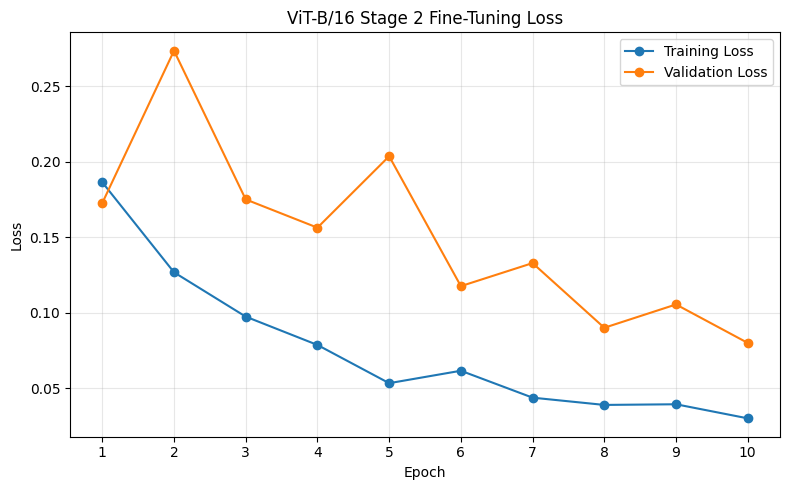

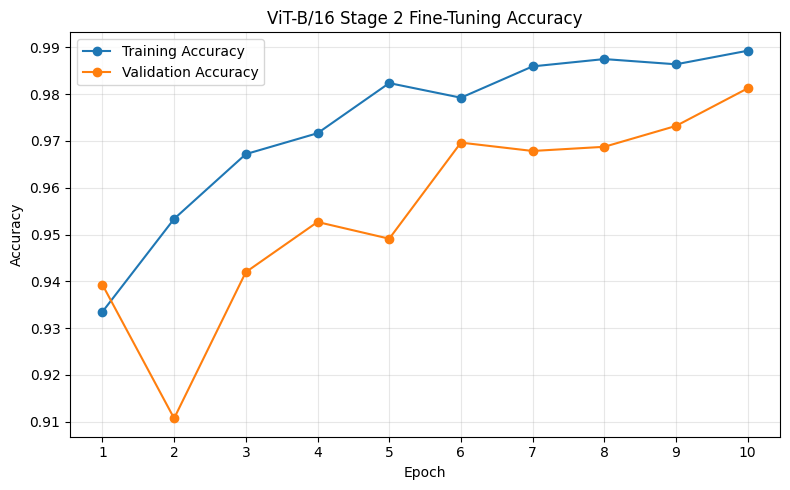

Saved:
/Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/figures/vit_stage2_loss.png
/Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/figures/vit_stage2_accuracy.png


In [63]:
# ============================================
# Stage 2 - Learning Curves
# ============================================

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    ft_epochs,
    ft_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    ft_epochs,
    ft_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT-B/16 Stage 2 Fine-Tuning Loss")
plt.xticks(list(ft_epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

ft_loss_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "vit_stage2_loss.png"
)

plt.savefig(
    ft_loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    ft_epochs,
    ft_history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    ft_epochs,
    ft_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT-B/16 Stage 2 Fine-Tuning Accuracy")
plt.xticks(list(ft_epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

ft_accuracy_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "vit_stage2_accuracy.png"
)

plt.savefig(
    ft_accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(ft_loss_path)
print(ft_accuracy_path)

In [64]:
# ============================================
# Stage 1 vs Stage 2 Comparison
# ============================================

stage1_best = max(history["val_accuracy"])
stage2_best = max(ft_history["val_accuracy"])

stage1_epoch = (
    np.argmax(history["val_accuracy"]) + 1
)

stage2_epoch = (
    np.argmax(ft_history["val_accuracy"]) + 1
)

print("Stage 1")
print("----------------------------")
print(
    f"Best validation accuracy: "
    f"{stage1_best * 100:.2f}%"
)
print("Best epoch:", stage1_epoch)

print("\nStage 2")
print("----------------------------")
print(
    f"Best validation accuracy: "
    f"{stage2_best * 100:.2f}%"
)
print("Best epoch:", stage2_epoch)

print("\nDifference")
print("----------------------------")
print(
    f"{(stage2_best - stage1_best) * 100:+.2f} percentage points"
)

Stage 1
----------------------------
Best validation accuracy: 92.14%
Best epoch: 5

Stage 2
----------------------------
Best validation accuracy: 98.12%
Best epoch: 10

Difference
----------------------------
+5.98 percentage points


In [65]:
# ============================================
# Final Evaluation - Load Best Fine-Tuned Model
# ============================================

FT_BEST_MODEL_PATH = (
    Path.home()
    / "brain-tumor-checkpoints"
    / "vit_b16_finetuned_best.pth"
)

print("Loading:")
print(FT_BEST_MODEL_PATH)

checkpoint = torch.load(
    FT_BEST_MODEL_PATH,
    map_location="cpu"
)

model.load_state_dict(checkpoint)
model = model.to(device)

print("\nBest fine-tuned ViT-B/16 checkpoint loaded.")

Loading:
/Users/mirshad/brain-tumor-checkpoints/vit_b16_finetuned_best.pth

Best fine-tuned ViT-B/16 checkpoint loaded.


In [66]:
# ============================================
# Final Test Predictions
# ============================================

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

test_loss = 0.0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        batch_size = labels.size(0)
        test_loss += loss.item() * batch_size
        test_total += batch_size

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

test_loss = test_loss / test_total

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Final test evaluation completed.")
print("Test samples:", len(all_labels))
print("Test loss:", test_loss)

Final test evaluation completed.
Test samples: 1600
Test loss: 0.6965088825648865


In [67]:
# ============================================
# Final Classification Metrics
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("FINAL TEST RESULTS")
print("==========================")
print(f"Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Precision: {test_precision:.4f} ({test_precision * 100:.2f}%)")
print(f"Recall   : {test_recall:.4f} ({test_recall * 100:.2f}%)")
print(f"F1-score : {test_f1:.4f} ({test_f1 * 100:.2f}%)")

print("\nClassification Report")
print("==========================")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

FINAL TEST RESULTS
Accuracy : 0.9350 (93.50%)
Precision: 0.9399 (93.99%)
Recall   : 0.9350 (93.50%)
F1-score : 0.9337 (93.37%)

Classification Report
              precision    recall  f1-score   support

      glioma     0.9938    0.7975    0.8849       400
  meningioma     0.8813    0.9650    0.9212       400
     notumor     0.9070    1.0000    0.9512       400
   pituitary     0.9775    0.9775    0.9775       400

    accuracy                         0.9350      1600
   macro avg     0.9399    0.9350    0.9337      1600
weighted avg     0.9399    0.9350    0.9337      1600



In [68]:
# ============================================
# Multiclass ROC-AUC
# ============================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(
    all_labels,
    classes=np.arange(NUM_CLASSES)
)

test_roc_auc = roc_auc_score(
    y_test_bin,
    all_probabilities,
    multi_class="ovr",
    average="macro"
)

print(
    f"Macro ROC-AUC: {test_roc_auc:.4f} "
    f"({test_roc_auc * 100:.2f}%)"
)

Macro ROC-AUC: 0.9849 (98.49%)


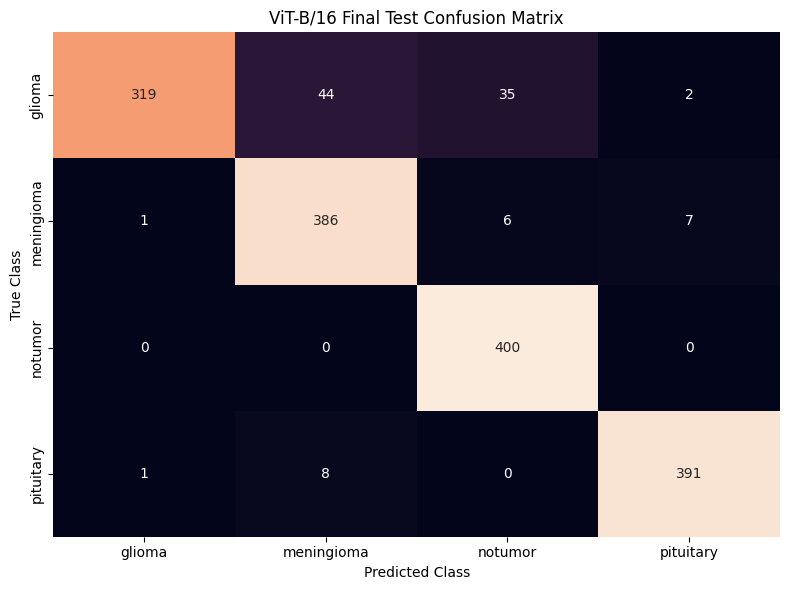

Confusion matrix saved to: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/figures/vit_b16_test_confusion_matrix.png


In [69]:
# ============================================
# Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cbar=False
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("ViT-B/16 Final Test Confusion Matrix")

plt.tight_layout()

cm_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "vit_b16_test_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:", cm_path)

In [70]:
# ============================================
# Save Final Test Results
# ============================================

final_results = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Macro ROC-AUC"
    ],
    "Value": [
        test_loss,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})

final_results_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "vit_b16_final_test_results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print(final_results)
print("\nSaved to:", final_results_path)

            Metric     Value
0        Test Loss  0.696509
1         Accuracy  0.935000
2  Macro Precision  0.939894
3     Macro Recall  0.935000
4   Macro F1-score  0.933718
5    Macro ROC-AUC  0.984851

Saved to: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/results/metrics/vit_b16_final_test_results.csv


In [71]:
# ============================================
# Validation vs Final Test
# ============================================

best_validation_accuracy = max(
    ft_history["val_accuracy"]
)

print("MODEL PERFORMANCE SUMMARY")
print("==============================")
print(
    f"Best Validation Accuracy: "
    f"{best_validation_accuracy * 100:.2f}%"
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Validation → Test Difference: "
    f"{(test_accuracy - best_validation_accuracy) * 100:+.2f} percentage points"
)

MODEL PERFORMANCE SUMMARY
Best Validation Accuracy: 98.12%
Final Test Accuracy: 93.50%
Validation → Test Difference: -4.62 percentage points
